# **LINEAR REGRESSION**
Created by **Ömer Türk**
****

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Dataset Creater Function and The Rule Function

In [2]:
def func(vals1, vals2):
  return vals1*3-vals2*2+random.randint(-1,1)

In [3]:
def create_dataset(n=300):
    vals1 = np.random.randint(1, 121, size=n)
    vals2 = np.random.randint(1, 151, size=n)
    df = pd.DataFrame({
        "val1": vals1,
        "val2": vals2,
        "cls": (func(vals1, vals2)).astype(int)
    })
    return df

## Simple data analysis on dataset

In [4]:
df = create_dataset(n=600)
df.head()

,val1,val2,cls
0,13,96,-154
1,51,145,-138
2,64,135,-79
3,119,142,72
4,16,50,-53


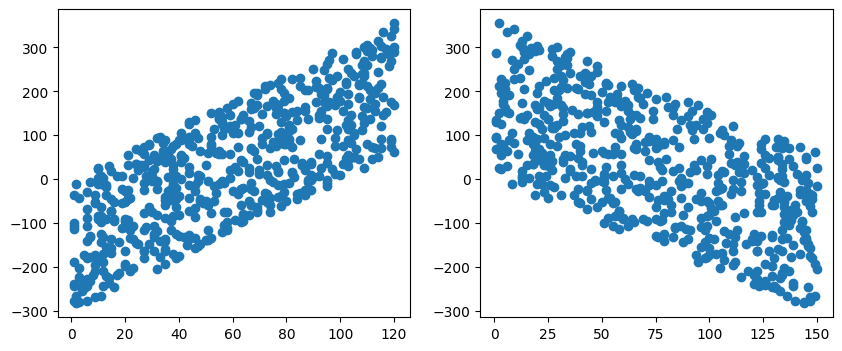

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))  # 1 satır, 2 sütun
axs[0].scatter(df.val1,df.cls)
axs[1].scatter(df.val2,df.cls)

## Linear Regression Class

In [6]:
class Lin_Reg:
    def __init__(self, iter=100, a=0.0001):
        self.iter = iter
        self.a = a
        self.Q = None
    def hypo_func(self, x):
        return np.asarray(x) @ self.Q
    def loss_func(self, X, Y):
        preds = X @ self.Q
        errors = preds - Y
        return float((errors.T @ errors) / (2 * X.shape[0]))
    def gradient_descent(self, X, Y):
        preds = X @ self.Q
        grad = (X.T @ (preds - Y)) / (X.shape[0])
        self.Q -= self.a * grad
    def predict(self, x):
        x = x.copy()
        x["bias"]=1
        result = self.hypo_func(x)
        return pd.Series(result)
    def fit(self, X, Y, logs=True):
        X = X.copy()
        Y = Y.copy()
        self.Q = np.zeros(X.shape[1]+1)
        X["bias"]=1
        for i in range(self.iter):
            self.gradient_descent(X, Y)
            if logs:
              print(f"Loss {i}:", self.loss_func(X, Y))
        print("Model is trained.")

## Split the dataset

In [7]:
X=df.drop(columns="cls")
Y=df["cls"]
X_train, X_test, y_train, y_test = train_test_split(
    X,Y,test_size=.3,random_state=42
)

In [8]:
X_train.head()

,val1,val2
108,91,31
272,30,47
599,107,53
479,76,39
436,3,115


In [9]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (420, 2)
X_test shape : (180, 2)
y_train shape: (420,)
y_test shape : (180,)


## Train the model and view the weights

In [10]:
lin=Lin_Reg()
lin.fit(X_train,y_train,logs=True)

Loss 0: 6954.85395829814
Loss 1: 5050.871097594307
Loss 2: 3668.236425670932
Loss 3: 2664.0928711731253
Loss 4: 1934.8296911887567
Loss 5: 1405.1994566578664
Loss 6: 1020.5534287700757
Loss 7: 741.202747441142
Loss 8: 538.3232229620256
Loss 9: 390.98117493426497
Loss 10: 283.9734361761153
Loss 11: 206.25864711980935
Loss 12: 149.817977238305
Loss 13: 108.8277195300521
Loss 14: 79.05838403070737
Loss 15: 57.4382871281451
Loss 16: 41.73660659733432
Loss 17: 30.333199081047297
Loss 18: 22.05142913585071
Loss 19: 16.036760673585093
Loss 20: 11.668583521369456
Loss 21: 8.496177116292245
Loss 22: 6.192203888477573
Loss 23: 4.518933648825084
Loss 24: 3.303713918637969
Loss 25: 2.4211551606726407
Loss 26: 1.7801927335821173
Loss 27: 1.3146905857791602
Loss 28: 0.9766171513908699
Loss 29: 0.7310893180324189
Loss 30: 0.5527730890385928
Loss 31: 0.4232695503459163
Loss 32: 0.32921641872728946
Loss 33: 0.2609092837797413
Loss 34: 0.21130027953092395
Loss 35: 0.17527086578088255
Loss 36: 0.14910368

In [11]:
lin.Q

,0
val1,2.992411
val2,-2.005628
bias,0.009732


## Make predictions and calculate the mean squared error

In [12]:
x=pd.Series({"val1":20,"val2":30})
print(lin.predict(x), func(x["val1"], x["val2"]))

0   -0.310886
dtype: float64 -1


In [13]:
test = create_dataset(n=200)
X_test, y_test = test.drop(columns="cls"), test["cls"]
y_pred = lin.predict(X_test)

In [14]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.8311264684872108
MSE : 0.8110268432142438
RMSE: 0.9005702877700573
R²  : 0.999956357689214


The R² metric is approximately 1 because the dataset was generated using simplified mathematical function. It is likely to not be that much close to 1 in a real-world scenario.

A sample from test and pred series:

In [15]:
y_test.loc[0], y_pred.loc[0]

(np.int64(189), np.float64(188.21103445784595))